In [1]:
import os
from os.path import join
import numpy as np
import pyntbci


In [2]:
wd = r'C:\Users\Radovan\OneDrive\Radboud\Studentships\Jordy Thielen\root'
os.chdir(wd)
data_dir = join(wd, "data")
experiment_dir = join(data_dir, "experiment")
files_dir = join(experiment_dir, 'files')
sourcedata_dir = join(experiment_dir, 'sourcedata')
derivatives_dir = join(join(experiment_dir, 'derivatives'))
os.chdir(wd)
data_dir = experiment_dir

In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

#data_dir = os.path.join(os.path.expanduser("~"), "data", "cvep_covert", "experiment")
#npz_data = np.load(file_path)
#subjects = ["VPpdia", "VPpdib"]
subjects = ["VPpdia","VPpdib", "VPpdic", "VPpdid", "VPpdie", "VPpdif", "VPpdig", "VPpdih", "VPpdii", "VPpdij",
            "VPpdik", "VPpdil", "VPpdim", "VPpdin", "VPpdio", "VPpdip", "VPpdiq", "VPpdir", "VPpdis", "VPpdit",
            "VPpdiu", "VPpdiv", "VPpdiw", "VPpdix", "VPpdiy", "VPpdiz", "VPpdiza", "VPpdizb", "VPpdizc"]
session = "S001"
tasks = ["overt", "covert"]



In [6]:
task = 'covert'
event = "dur"
onset_event = True
encoding_length = 0.3
ensemble = True
n_folds = 4
segments = np.linspace(5, 80, 16, dtype=int)*0.250
n_segments = segments.size
# Loop participants
accuracy = np.zeros((len(subjects), n_folds, n_segments))

for i_subject, subject in enumerate(subjects):
    print(f"{subject}")

    # Load data
    file_dir = os.path.join(derivatives_dir, 'preprocessed', "cvep", f"sub-{subject}")
    fn = os.path.join(file_dir, f"sub-{subject}_task-{task}_cvep_64_noica.npz")
    tmp = np.load(fn)
    fs = int(tmp["fs"])
    X = tmp["X"]
    y = tmp["y"]
    V = tmp["V"]
    
    # Cross-validation
    folds = np.repeat(np.arange(n_folds), int(X.shape[0] / n_folds))
    for i_fold in range(n_folds):
        # Split data to train and test set
        X_trn, y_trn = X[folds != i_fold, :, :], y[folds != i_fold]
        X_tst, y_tst = X[folds == i_fold, :, :], y[folds == i_fold]

        # Train classifier
        rcca = pyntbci.classifiers.rCCA(stimulus=V, fs=fs, event=event, encoding_length=encoding_length,
                                        onset_event=onset_event, ensemble=ensemble)
        rcca.fit(X_trn, y_trn)

        # Loop segments
        for i_segment in range(n_segments):
        # Apply classifier
            yh_tst = rcca.predict(X_tst[:, :, :int(fs * segments[i_segment])])

            # Compute accuracy
            accuracy[i_subject, i_fold, i_segment] = np.mean(yh_tst == y_tst)



VPpdia	VPpdib	VPpdic	VPpdid	VPpdie	VPpdif	VPpdig	VPpdih	VPpdii	VPpdij	VPpdik	VPpdil	VPpdim	VPpdin	VPpdio	VPpdip	VPpdiq	VPpdir	VPpdis	VPpdit	VPpdiu	VPpdiv	VPpdiw	VPpdix	VPpdiy	VPpdiz	VPpdiza	VPpdizb	VPpdizc	

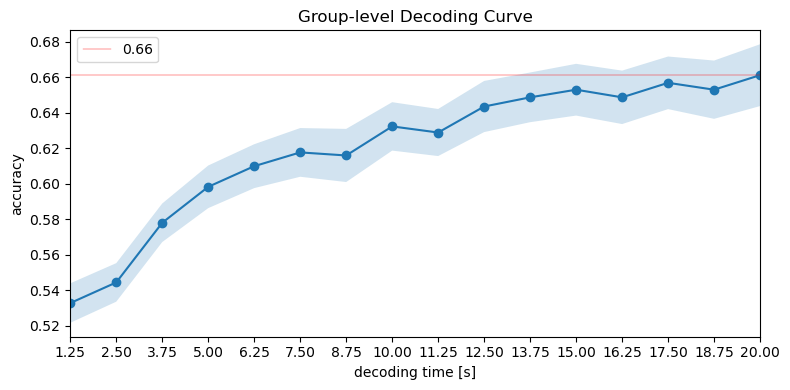

In [7]:
import matplotlib.pyplot as plt
# 1) Subject‐level mean across folds -> (n_subjects, n_segments)
sub_avg = accuracy.mean(axis=1)

# 2) Group mean & SE across subjects -> (n_segments,)
group_avg = sub_avg.mean(axis=0)
group_se  = sub_avg.std(axis=0, ddof=1) / np.sqrt(sub_avg.shape[0])

# Plot decoding curve
plt.figure(figsize=(8, 4))
plt.plot(segments, group_avg, marker='o', linestyle='-')
plt.fill_between(segments, group_avg + group_se, group_avg - group_se, alpha=0.2)
plt.xlabel('decoding time [s]')
plt.ylabel('accuracy')
plt.title('Group‐level Decoding Curve')
plt.axhline(group_avg[-1], color = 'red', alpha = 1,
             linewidth = 0.3, label = f'{group_avg[-1]:.2f}')
# Decimate x-axis to 16 ticks between min and max segment
ticks = np.linspace(5, 80, 16, dtype=int)*0.250
plt.xticks(ticks)
plt.xlim(segments.min(), segments.max())
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
## Photo-ready saving
manuscript_dir = r'C:\Users\Radovan\OneDrive\Radboud\Studentships\Jordy Thielen\Manuscript\data'
m_ica_dir = join(manuscript_dir, 'ica')
m_noica_dir = join(manuscript_dir, 'noica')
save_path = os.path.join(m_noica_dir, "covert_lda_cvep_decC_64_noica.npz")

n_subjects = accuracy.shape[0]
sub_means = accuracy.mean(axis=1)
group_mean = sub_means.mean(axis=0)
sem_sub    = sub_means.std(axis=0, ddof=1)/ np.sqrt(n_subjects)

# pack results
group_results = {
    'time_window'     : segments,
    'mean_accuracy'   : group_mean,
    'standard_error'  : sem_sub
}


np.savez(
    save_path,
    epoch_bins=group_results['time_window'],
    mean_accuracies=group_results['mean_accuracy'],
    se_accuracies=group_results['standard_error']
)

print(f"results saved to {save_path}")

results saved to C:\Users\Radovan\OneDrive\Radboud\Studentships\Jordy Thielen\Manuscript\data\noica\covert_lda_cvep_decC_64_noica.npz
